# Dynamic and Adaptive Attention — Practical Implementation 4

**Models used**
- `openai-community/gpt2` — decoder-only causal language model.
- `distilbert/distilbert-base-uncased` — encoder-only masked-language model.

This notebook connects to the report's themes: **content-dependent sparse attention (top-k), adaptive context/span, dynamic token selection/pruning, and memory-aware attention**.

> Important experimental distinction: GPT-2 and DistilBERT are pretrained dense-attention models. We inspect their *actual learned attention maps*, then run controlled interventions (top-k filtering and token masking) on those maps/inputs. These experiments demonstrate dynamic/adaptive ideas; they do **not** claim that the original checkpoints were trained with a learned sparse-routing mechanism.

## 0) Setup

The first model load downloads pretrained weights from Hugging Face, so internet access is required once. GPT-2 is small enough for a typical CPU or free Colab GPU.

In [1]:
# Install the Transformers stack used by the experiments below.
# Pin Transformers to the 4.x series for API compatibility, while also
# installing Accelerate and Safetensors for model loading and execution.
%pip -q install "transformers>=4.45,<5" "accelerate>=0.30" safetensors

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 36.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.27.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
# Import the core libraries, set reproducible random seeds, and select the
# available compute device. The Transformers classes are used to load
# causal and masked language models for the experiments below.
import math, warnings, numpy as np, torch, matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForMaskedLM

SEED = 7
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.11.0+cpu
Device: cpu


## 1) Load open-weight models

We use GPT-2 for causal next-token prediction and DistilBERT for bidirectional masked-language modelling. Both expose attention weights through `output_attentions=True` in Transformers. The returned attention tensor for each layer has shape `(batch, heads, query_length, key_length)`.

In [3]:
# Load GPT-2 as a causal language model and DistilBERT as a masked language
# model. Both use eager attention so their attention tensors are accessible
# for inspection in the experiments below.
#
# The tokenizers prepare inputs for each model, while the final prints report
# the number of transformer layers and attention heads in each architecture.

GPT2_ID = "openai-community/gpt2"
DISTILBERT_ID = "distilbert/distilbert-base-uncased"

gpt_tok = AutoTokenizer.from_pretrained(GPT2_ID)
gpt = AutoModelForCausalLM.from_pretrained(
    GPT2_ID, attn_implementation="eager"
).to(device).eval()

bert_tok = AutoTokenizer.from_pretrained(DISTILBERT_ID)
bert = AutoModelForMaskedLM.from_pretrained(
    DISTILBERT_ID, attn_implementation="eager"
).to(device).eval()

print("GPT-2 layers / heads:", gpt.config.n_layer, "/", gpt.config.n_head)
print("DistilBERT layers / heads:", bert.config.n_layers, "/", bert.config.n_heads)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

GPT-2 layers / heads: 12 / 12
DistilBERT layers / heads: 6 / 12


## 2) Inspect actual attention in GPT-2

The model is causal: a token cannot attend to future positions. Compare attention for two different inputs. The attention patterns are input-conditioned because Q/K representations depend on the text, even though the architecture uses dense causal attention.

In [4]:
# Run both prompts through GPT-2 and retain the attention weights from every
# transformer layer. The helper keeps inference gradient-free and disables
# KV caching so the returned attention tensors correspond directly to the
# full input sequence.
#
# Each attention tensor has shape:
#   [batch, heads, query_tokens, key_tokens]
#
# We use the final layer below for inspection and comparison between prompts.

prompts = [
    "The scientist placed the sample in the laboratory. Later, the scientist",
    "In the garden, the gardener watered the flowers. Later, the gardener"
]

def gpt_forward(text, output_attentions=True):
    batch = gpt_tok(text, return_tensors="pt").to(device)
    with torch.no_grad():
        out = gpt(**batch, output_attentions=output_attentions, use_cache=False)
    return batch, out

batch_a, out_a = gpt_forward(prompts[0])
batch_b, out_b = gpt_forward(prompts[1])
att_a = out_a.attentions
print("Layers:", len(att_a), "| attention tensor:", tuple(att_a[-1].shape))

Layers: 12 | attention tensor: (1, 12, 13, 13)


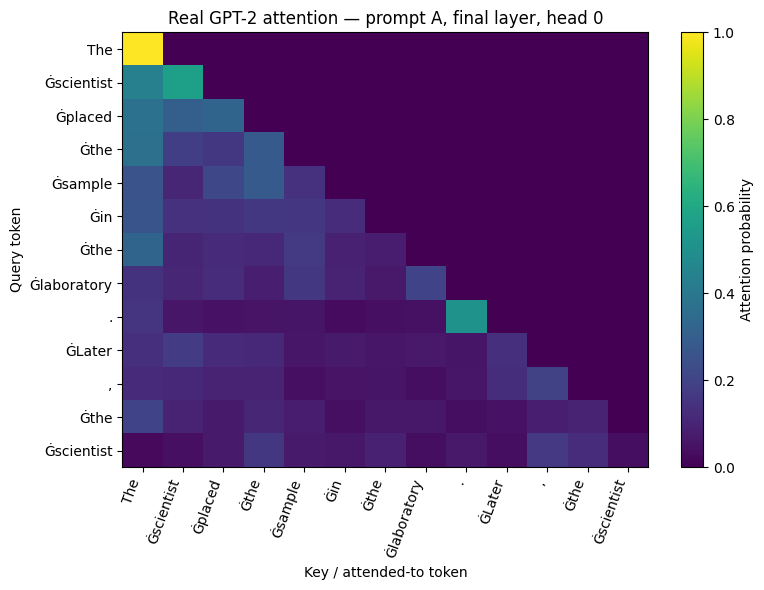

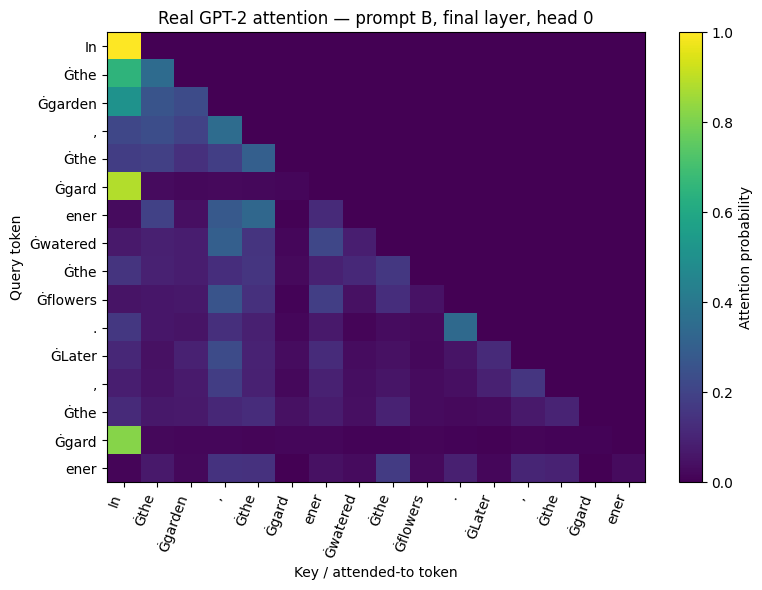

In [5]:
# Visualize real GPT-2 attention weights for a selected layer and attention head.
# Each heatmap shows how strongly every query token attends to every key token.
# Rows correspond to query tokens, columns correspond to attended-to tokens.
#
# The attention weights are moved to CPU and converted to NumPy for plotting.
# Token IDs are converted back into GPT-2's token strings for readable axis
# labels. The two plots below compare the same attention head on both prompts,
# using the final transformer layer.

def plot_attention(attentions, input_ids, layer=-1, head=0, title=""):
    weights = attentions[layer][0, head].detach().float().cpu().numpy()
    toks = gpt_tok.convert_ids_to_tokens(input_ids[0].tolist())
    fig, ax = plt.subplots(figsize=(max(8, len(toks)*0.48), 6))
    im = ax.imshow(weights, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(toks))); ax.set_xticklabels(toks, rotation=70, ha="right")
    ax.set_yticks(range(len(toks))); ax.set_yticklabels(toks)
    ax.set_xlabel("Key / attended-to token"); ax.set_ylabel("Query token")
    ax.set_title(title or f"GPT-2 layer {layer}, head {head}")
    fig.colorbar(im, ax=ax, label="Attention probability")
    plt.tight_layout(); plt.show()

plot_attention(att_a, batch_a["input_ids"], layer=-1, head=0,
               title="Real GPT-2 attention — prompt A, final layer, head 0")
plot_attention(out_b.attentions, batch_b["input_ids"], layer=-1, head=0,
               title="Real GPT-2 attention — prompt B, final layer, head 0")

### Discussion
- The triangular structure is the causal constraint.
- Differences between prompts arise from the model's learned, content-dependent Q/K scores.
- Heads can distribute attention differently; no single head should be assumed to have a fixed semantic role from one visualization.

## 3) Dynamic top-k attention: sparsify each query's real attention row

For each query token and head, retain only its `k` largest attention weights and renormalize the retained weights to sum to one. Because the selected keys depend on the current input's attention scores, this is **content-dependent sparsification**.

This section operates on attention probabilities returned by the real model. It is a post-hoc intervention for analysis, not a replacement sparse kernel inside GPT-2's forward pass.

In [6]:
# Keep only the top-k attention keys for every query/head independently.
# The selected attention probabilities are renormalized so each sparse
# attention distribution still sums to 1.
#
# This gives a simple per-query sparsification baseline: instead of storing
# attention to every key, only the k highest-probability keys are retained.
# The density calculation shows what fraction of the original attention
# matrix remains nonzero after sparsification.

def per_query_topk(attn, k):
    # attn: [batch, heads, query, key], probabilities after softmax
    k = min(k, attn.shape[-1])
    vals, idx = torch.topk(attn, k=k, dim=-1)
    sparse = torch.zeros_like(attn).scatter_(-1, idx, vals)
    sparse = sparse / sparse.sum(dim=-1, keepdim=True).clamp_min(1e-12)
    return sparse, idx

dense = att_a[-1].detach()
k = 3
sparse, chosen = per_query_topk(dense, k)
density = (sparse > 0).float().mean().item()
print(f"Retained keys per query/head: {k}")
print(f"Nonzero density: {density:.3f} (dense matrix density = 1.0)")

Retained keys per query/head: 3
Nonzero density: 0.213 (dense matrix density = 1.0)


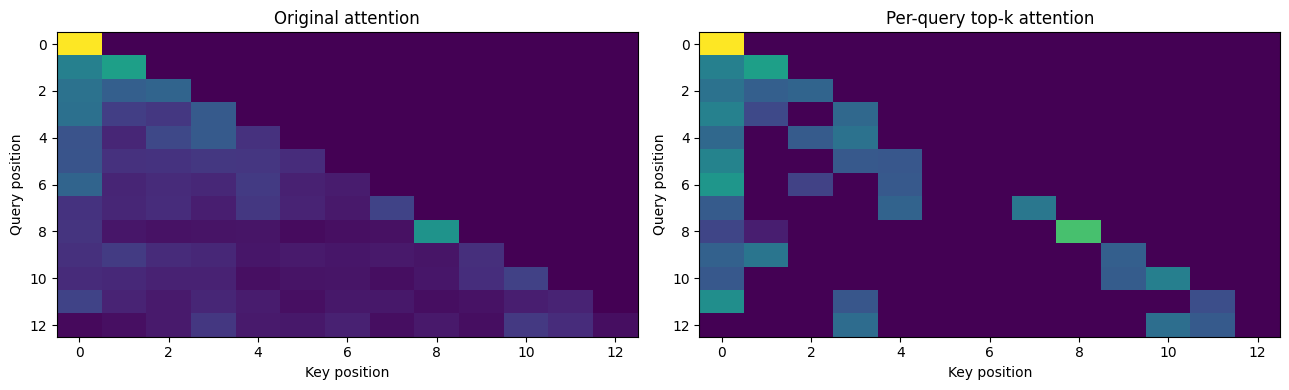

Mean original probability mass retained before renormalization: 0.888


In [7]:
# Compare the original dense attention map with its per-query top-k version.
# The first heatmap shows the full attention distribution, while the second
# shows only the selected high-probability keys.
#
# The retained-mass calculation measures how much of the original attention
# probability was covered by the selected top-k keys before renormalization.
# This separates sparsity from information retention: a sparse map can still
# preserve a large fraction of the original attention mass.

def compare_dense_sparse(dense, sparse, head=0):
    d = dense[0, head].float().cpu().numpy()
    s = sparse[0, head].float().cpu().numpy()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].imshow(d, aspect="auto", cmap="viridis"); axes[0].set_title("Original attention")
    axes[1].imshow(s, aspect="auto", cmap="viridis"); axes[1].set_title("Per-query top-k attention")
    for ax in axes: ax.set_xlabel("Key position"); ax.set_ylabel("Query position")
    plt.tight_layout(); plt.show()

compare_dense_sparse(dense, sparse, head=0)

# Quantify how much probability mass the selected keys retained before renormalization.
retained_mass = torch.gather(dense, -1, chosen).sum(-1).mean().item()
print(f"Mean original probability mass retained before renormalization: {retained_mass:.3f}")

### Sweep k: sparsity versus retained attention mass

Smaller `k` gives a sparser map but may discard more of the original attention probability mass. The retained-mass curve is descriptive; it is not by itself a measure of downstream language-model quality.

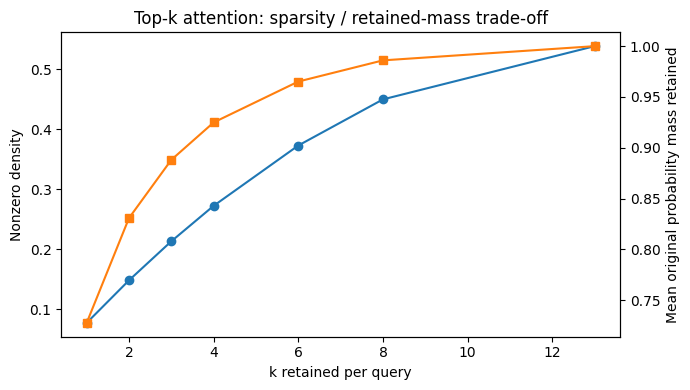

In [8]:
# Sweep several top-k values to measure the trade-off between attention
# sparsity and how much of the original probability mass is retained.
#
# Smaller k produces a sparser attention pattern, while larger k preserves
# more of the original attention distribution. The plot shows both metrics
# together so the effect of increasing the number of retained keys is clear.

ks = sorted(set([1, 2, 3, 4, 6, 8, dense.shape[-1]]))
densities, masses = [], []
for kk in ks:
    sp, ix = per_query_topk(dense, kk)
    densities.append((sp > 0).float().mean().item())
    masses.append(torch.gather(dense, -1, ix).sum(-1).mean().item())

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(ks, densities, marker="o", label="Nonzero density")
ax1.set_xlabel("k retained per query"); ax1.set_ylabel("Nonzero density")
ax2 = ax1.twinx()
ax2.plot(ks, masses, marker="s", label="Original mass retained", color="tab:orange")
ax2.set_ylabel("Mean original probability mass retained")
plt.title("Top-k attention: sparsity / retained-mass trade-off")
plt.tight_layout(); plt.show()

## 4) Adaptive context span: measure head-specific context use

Adaptive attention span as allows different heads to use different context lengths. Here we estimate an **effective span** from the real GPT-2 attention maps: for each head, calculate the average attention mass by backward distance and find the smallest distance containing 90% of that mass.

This is an empirical diagnostic, not a learned span parameter. GPT-2's original weights are not modified.

90%-mass effective span, prompt A: [10, 12, 12, 12, 12, 12, 12, 12, 9, 12, 12, 12]
90%-mass effective span, prompt B: [14, 15, 15, 15, 15, 15, 15, 15, 10, 15, 15, 15]


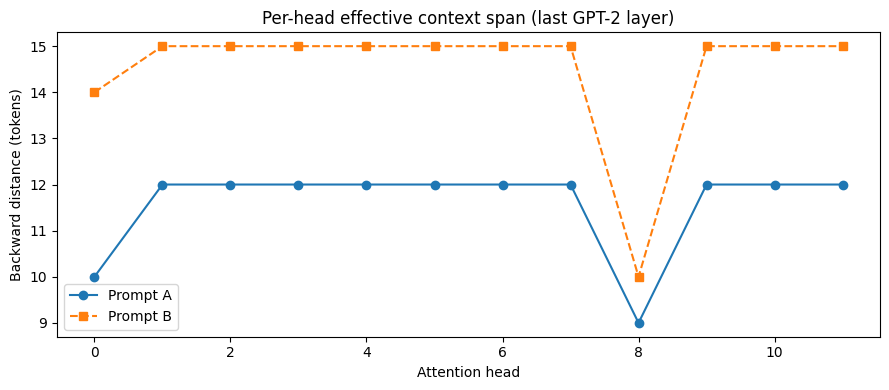

In [9]:
# Estimate the effective backward context span for each GPT-2 attention head.
# For every head, attention probability is grouped by query-to-key distance
# and normalized into a distance profile.
#
# The 90%-mass span is the smallest backward distance containing at least
# 90% of the profile's total attention mass. The final plot compares these
# spans across heads for the two prompts.

def effective_span_by_head(attention, mass_threshold=0.90):
    # attention: [batch, heads, Q, K], causal self-attention
    a = attention[0].float()
    H, Q, K = a.shape
    distances = torch.arange(Q, device=a.device)[:, None] - torch.arange(K, device=a.device)[None, :]
    valid = distances >= 0
    spans = []
    profiles = []
    for h in range(H):
        profile = []
        for d in range(Q):
            profile.append(a[h][(distances == d)].mean().item() if (distances == d).any() else 0.0)
        p = torch.tensor(profile)
        p = p / p.sum().clamp_min(1e-12)
        c = torch.cumsum(p, 0)
        span = int(torch.searchsorted(c, torch.tensor(mass_threshold)).item()) if c[-1] >= mass_threshold else Q-1
        spans.append(span)
        profiles.append(p.numpy())
    return spans, np.array(profiles)

spans_a, profiles_a = effective_span_by_head(att_a[-1])
spans_b, profiles_b = effective_span_by_head(out_b.attentions[-1])
print("90%-mass effective span, prompt A:", spans_a)
print("90%-mass effective span, prompt B:", spans_b)

plt.figure(figsize=(9, 4))
plt.plot(range(len(spans_a)), spans_a, "o-", label="Prompt A")
plt.plot(range(len(spans_b)), spans_b, "s--", label="Prompt B")
plt.xlabel("Attention head"); plt.ylabel("Backward distance (tokens)")
plt.title("Per-head effective context span (last GPT-2 layer)")
plt.legend(); plt.tight_layout(); plt.show()

**Interpretation:** head-specific spans and changes between prompts illustrate why a single fixed context window may not describe all attention behaviour. The measured span depends on this prompt, layer, and chosen 90% threshold; it is not a claim that the model learned an explicit adaptive-span controller.

## 5) Dynamic token selection / pruning with a real forward pass

We derive token importance from the real model's final-layer attention: sum attention received by each key position, averaged over heads and queries. Then keep the most attended tokens (plus the final token) and rerun GPT-2 with an attention mask that hides the other positions as keys.

This is a practical **input-token masking intervention**. It does not physically shorten the sequence or guarantee lower runtime; it tests how the model's next-token distribution changes when selected context tokens are unavailable.

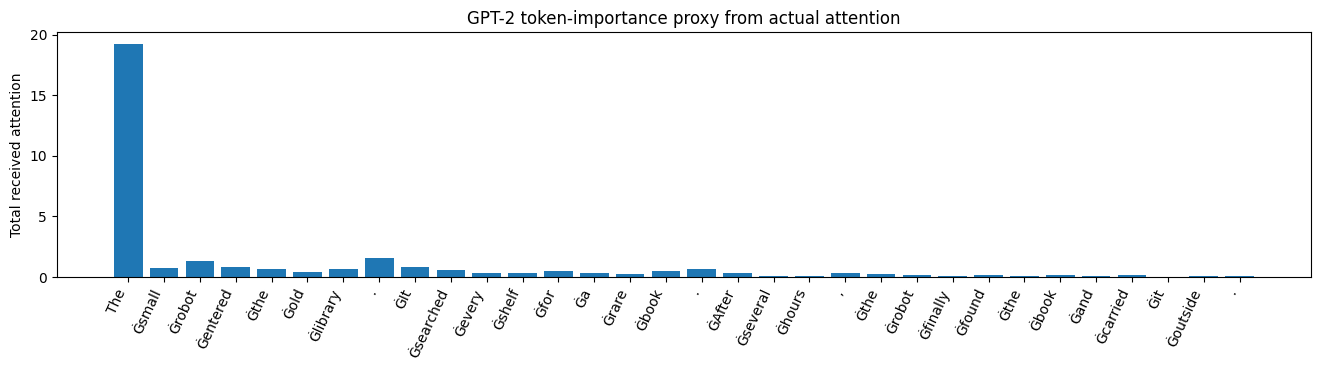

In [10]:
# Measure a simple token-importance proxy from GPT-2's actual attention.
# Attention is averaged across heads and then summed across all query
# positions, giving the total attention mass received by each key token.
#
# This highlights which tokens receive more attention overall in the final
# layer for the given sequence. It is an attention-based diagnostic rather
# than a direct measure of model feature importance.

text = ("The small robot entered the old library. It searched every shelf for a rare book. "
        "After several hours, the robot finally found the book and carried it outside.")
inputs, outputs = gpt_forward(text)
ids = inputs["input_ids"]
last_attn = outputs.attentions[-1][0]  # [heads, Q, K]
importance = last_attn.mean(dim=0).sum(dim=0)  # received attention by key position
tokens = gpt_tok.convert_ids_to_tokens(ids[0].tolist())

plt.figure(figsize=(max(9, len(tokens)*0.42), 3.8))
plt.bar(range(len(tokens)), importance.detach().cpu().numpy())
plt.xticks(range(len(tokens)), tokens, rotation=65, ha="right")
plt.ylabel("Total received attention")
plt.title("GPT-2 token-importance proxy from actual attention")
plt.tight_layout(); plt.show()

In [11]:
# Test whether an attention-based token selection can preserve GPT-2's
# next-token predictions when part of the input context is masked.
#
# The highest-attention tokens are retained up to the chosen fraction, while
# the final token is always kept because its hidden state produces the next
# token prediction. The full and masked contexts are then compared using
# their next-token distributions and KL divergence.
#
# The top-token helper makes it easy to inspect whether the most likely
# predictions change after removing part of the context.

def masked_context_experiment(input_ids, importance, keep_fraction=0.60):
    n = input_ids.shape[1]
    keep_n = max(2, int(math.ceil(n * keep_fraction)))
    selected = torch.topk(importance, k=min(keep_n, n)).indices
    # Always retain the final input token, since its hidden state predicts next token.
    selected = torch.unique(torch.cat([selected, torch.tensor([n-1], device=selected.device)]))
    mask = torch.zeros((1, n), dtype=torch.long, device=device)
    mask[0, selected] = 1
    with torch.no_grad():
        full = gpt(input_ids=input_ids, attention_mask=torch.ones_like(input_ids),
                   use_cache=False).logits[0, -1]
        pruned = gpt(input_ids=input_ids, attention_mask=mask,
                     use_cache=False).logits[0, -1]
    p = torch.softmax(full.float(), dim=-1)
    q = torch.softmax(pruned.float(), dim=-1)
    kl = torch.sum(p * (torch.log(p.clamp_min(1e-12)) - torch.log(q.clamp_min(1e-12)))).item()
    return mask, full, pruned, kl

mask, full_logits, pruned_logits, kl = masked_context_experiment(ids, importance, 0.60)
print("Tokens kept:", int(mask.sum()), "/", mask.numel())
print("KL(full next-token distribution || masked-context distribution):", round(kl, 5))

def top_tokens(logits, n=8):
    vals, ix = torch.topk(logits, n)
    return [(gpt_tok.decode([i]), round(v.item(), 3)) for v, i in zip(vals, ix)]

print("\nFull-context top predictions:", top_tokens(full_logits))
print("Masked-context top predictions:", top_tokens(pruned_logits))

Tokens kept: 21 / 32
KL(full next-token distribution || masked-context distribution): 2.48164

Full-context top predictions: [('\n', -109.043), (' The', -110.446), (' It', -110.892), (' When', -112.22), ('\n\n', -112.296), (' After', -112.385), (' As', -112.428), (' A', -112.552)]
Masked-context top predictions: [(' robot', -77.075), (' book', -77.089), (' Robot', -77.655), (' Small', -78.156), (' books', -78.651), (' The', -78.668), (' Book', -78.772), (' It', -78.912)]


### Compare several keep ratios

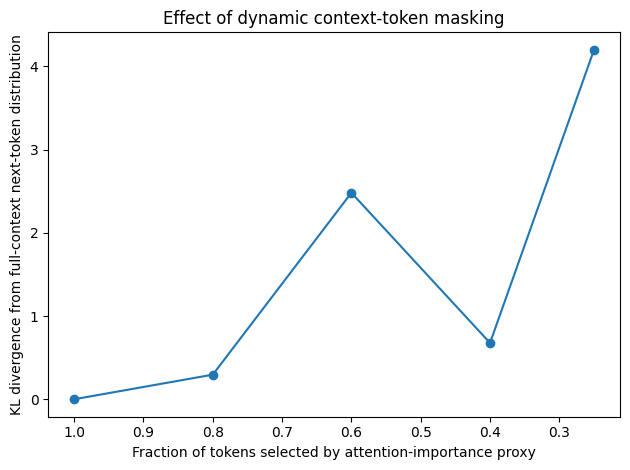

In [12]:
# Sweep different context-retention fractions and measure how masking tokens
# changes GPT-2's next-token probability distribution.
#
# For each fraction, the attention-importance proxy selects the corresponding
# number of tokens. The KL divergence from the full-context distribution is
# then used to quantify how much the prediction distribution changes.
#
# The x-axis is inverted so the plot moves from the full context toward more
# aggressive token removal.

ratios, kls = [1.0, 0.8, 0.6, 0.4, 0.25], []
for r in ratios:
    _, _, _, value = masked_context_experiment(ids, importance, r)
    kls.append(value)
plt.plot(ratios, kls, marker="o")
plt.xlabel("Fraction of tokens selected by attention-importance proxy")
plt.ylabel("KL divergence from full-context next-token distribution")
plt.title("Effect of dynamic context-token masking")
plt.gca().invert_xaxis()
plt.tight_layout(); plt.show()

## 6) Repeat attention inspection with encoder-only DistilBERT

DistilBERT uses bidirectional self-attention, unlike GPT-2's causal attention. We inspect a masked-language example and visualize one head. This demonstrates that dynamic, content-dependent attention patterns also occur in an encoder model, while the visibility pattern differs.

DistilBERT attention tensor: (1, 12, 15, 15)


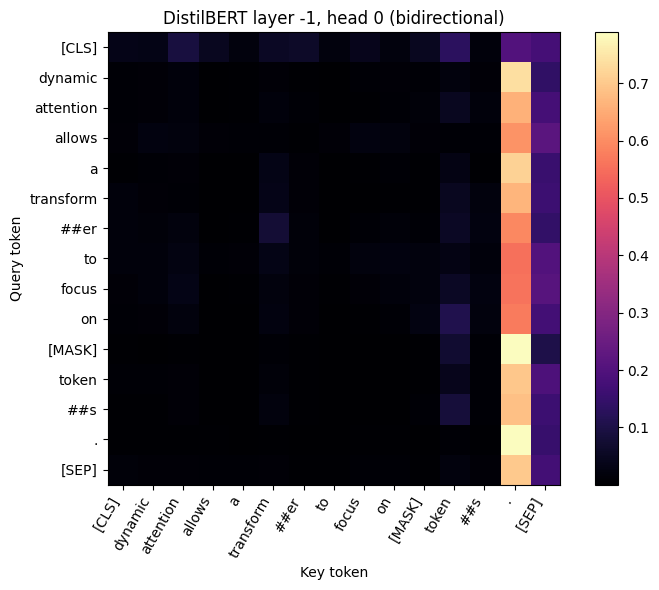

In [13]:
# Run a masked-language-model example through DistilBERT and inspect its
# attention weights. Unlike GPT-2's causal attention, DistilBERT uses
# bidirectional self-attention, so each token can attend to tokens on both
# sides of the sequence.
#
# The heatmap shows attention for one selected layer and head, with rows
# representing query tokens and columns representing key tokens.

bert_text = "Dynamic attention allows a transformer to focus on [MASK] tokens."
b_inputs = bert_tok(bert_text, return_tensors="pt").to(device)
with torch.no_grad():
    b_out = bert(**b_inputs, output_attentions=True)
b_att = b_out.attentions
b_tokens = bert_tok.convert_ids_to_tokens(b_inputs["input_ids"][0].tolist())
print("DistilBERT attention tensor:", tuple(b_att[-1].shape))

def plot_bert_attention(layer=-1, head=0):
    mat = b_att[layer][0, head].detach().float().cpu().numpy()
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(mat, cmap="magma")
    ax.set_xticks(range(len(b_tokens))); ax.set_xticklabels(b_tokens, rotation=60, ha="right")
    ax.set_yticks(range(len(b_tokens))); ax.set_yticklabels(b_tokens)
    ax.set_title(f"DistilBERT layer {layer}, head {head} (bidirectional)")
    ax.set_xlabel("Key token"); ax.set_ylabel("Query token")
    fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

plot_bert_attention()

In [14]:
# Find the [MASK] token in the DistilBERT input and inspect the model's
# highest-scoring predictions for that position.
#
# The logits at the masked position represent scores for every vocabulary
# token. The top-8 token IDs are selected and decoded back into readable
# token strings.

mask_pos = (b_inputs["input_ids"][0] == bert_tok.mask_token_id).nonzero(as_tuple=True)[0].item()
mask_logits = b_out.logits[0, mask_pos]
pred_ids = torch.topk(mask_logits, 8).indices.tolist()
print("Masked token:", bert_tok.mask_token)
print("Top predictions:", [bert_tok.decode([i]) for i in pred_ids])

Masked token: [MASK]
Top predictions: ['input', 'static', 'switching', 'arbitrary', 'specific', 'detecting', 'discrete', 'dynamic']


## 7) Practical findings

1. **Real-model inspection:** pretrained GPT-2 and DistilBERT return learned attention tensors; GPT-2 shows causal structure while DistilBERT is bidirectional.
2. **Dynamic sparse attention:** per-query top-k keeps a different set of keys according to each actual attention row. The notebook measures sparsity and retained probability mass.
3. **Adaptive context:** effective 90%-mass span varies across heads and can vary across inputs. This is a diagnostic proxy, not a learned span parameter.
4. **Token selection:** an attention-derived importance score selects context tokens; an actual second GPT-2 forward pass tests the effect of masking those tokens on next-token predictions.

**Main conclusion:** modern Transformer attention can be studied as input-dependent allocation of attention across tokens and heads. Practical adaptive mechanisms target selective interactions, context length, token retention, and inference memory.

## References and model provenance

- GPT-2 model: [openai-community/gpt2](https://huggingface.co/openai-community/gpt2)
- GPT-2 Transformers documentation: [GPT-2 model documentation](https://huggingface.co/docs/transformers/model_doc/gpt2)
- DistilBERT model card (Apache-2.0 license): [distilbert/distilbert-base-uncased](https://huggingface.co/distilbert/distilbert-base-uncased)
- DistilBERT Transformers documentation: [DistilBERT model documentation](https://huggingface.co/docs/transformers/model_doc/distilbert)